# Base 5 — ouro semanal: Random Forest para Retorno do ouro + Calculo para preço

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'projeto.yaml').is_file() or (candidate / 'config' / 'projeto.yaml').is_file():
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')


ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from series_temporais.data.preparacao_base5 import selecionar_alvos_observados

In [2]:
PRIMITIVAS = ['DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE']


def preparar_ouro_semanal(dados, regra_semanal='W-FRI'):
    ausentes = sorted(set(PRIMITIVAS).difference(dados.columns))
    if ausentes:
        raise KeyError(f'Colunas primitivas ausentes: {ausentes}')
    diario = dados[PRIMITIVAS].copy()
    diario['DATE'] = pd.to_datetime(diario['DATE'], errors='raise')
    if diario['DATE'].isna().any() or diario['DATE'].duplicated().any():
        raise ValueError('DATE deve ser completa e única.')
    diario = diario.sort_values('DATE', kind='stable')
    for coluna in PRIMITIVAS[1:]:
        diario[coluna] = pd.to_numeric(diario[coluna], errors='coerce')
    if diario['GOLD_PRICE'].isna().any() or diario['GOLD_PRICE'].le(0).any():
        raise ValueError('GOLD_PRICE deve ser positivo e não ausente.')

    diario['semana'] = diario['DATE'].dt.to_period(regra_semanal).dt.end_time.dt.normalize()
    agrupado = diario.groupby('semana', sort=True)
    semanal = agrupado.agg(
        price_t=('GOLD_PRICE', 'last'),
        treasury_10y_t=('TREASURY_10Y', 'last'),
        fed_funds_rate_t=('FED_FUNDS_RATE', 'last'),
        source_observations=('DATE', 'size'),
        last_quote_date=('DATE', 'max'),
    )
    grade = pd.date_range(semanal.index.min(), semanal.index.max(), freq=regra_semanal)
    semanal = semanal.reindex(grade)
    semanal.index.name = 'DATE'
    semanal['source_observations'] = semanal['source_observations'].fillna(0).astype(int)
    semanal['price_was_carried'] = semanal['source_observations'].eq(0)
    estado = ['price_t', 'treasury_10y_t', 'fed_funds_rate_t', 'last_quote_date']
    semanal[estado] = semanal[estado].ffill()
    if semanal[estado].isna().any().any():
        raise ValueError('A primeira semana não possui estado conhecido para propagação.')
    semanal['quote_age_days'] = (
        semanal.index.to_series().sub(semanal['last_quote_date']).dt.days.to_numpy()
    )
    semanal['log_price_t'] = np.log(semanal['price_t'])
    semanal['log_return_t'] = semanal['log_price_t'].diff()
    return semanal.reset_index()


def construir_quadro_ouro(semanal):
    requeridas = {
        'DATE', 'price_t', 'treasury_10y_t', 'fed_funds_rate_t',
        'source_observations', 'price_was_carried', 'quote_age_days',
        'log_price_t', 'log_return_t',
    }
    ausentes = sorted(requeridas.difference(semanal.columns))
    if ausentes:
        raise KeyError(f'Colunas semanais ausentes: {ausentes}')
    quadro = semanal.copy()
    quadro['DATE'] = pd.to_datetime(quadro['DATE'], errors='raise')
    if not quadro['DATE'].is_monotonic_increasing:
        raise ValueError('A série semanal deve estar em ordem crescente.')
    if not quadro['DATE'].diff().dropna().eq(pd.Timedelta(days=7)).all():
        raise ValueError('A série semanal deve possuir grade regular de sete dias.')

    quadro['target_date'] = quadro['DATE'].shift(-1)
    quadro['target_price_t_plus_1'] = quadro['price_t'].shift(-1)
    quadro['target_log_return_t_plus_1'] = quadro['log_return_t'].shift(-1)
    quadro['target_has_new_quote'] = quadro['source_observations'].shift(-1).gt(0).astype(int)
    quadro['has_source_observation_t'] = quadro['source_observations'].gt(0).astype(int)
    quadro['price_was_carried'] = quadro['price_was_carried'].astype(int)

    features = [
        'price_t', 'treasury_10y_t', 'fed_funds_rate_t', 'log_price_t',
        'log_return_t', 'source_observations', 'has_source_observation_t',
        'price_was_carried', 'quote_age_days',
    ]
    quadro['treasury_change_t'] = quadro['treasury_10y_t'].diff()
    quadro['fed_funds_change_t'] = quadro['fed_funds_rate_t'].diff()
    features.extend(['treasury_change_t', 'fed_funds_change_t'])

    for lag in (1, 4, 13, 26, 52):
        nome = f'price_lag_{lag}'
        quadro[nome] = quadro['price_t'].shift(lag)
        features.append(nome)
    for lag in (1, 2, 4, 8, 13, 26, 52):
        nome = f'return_lag_{lag}'
        quadro[nome] = quadro['log_return_t'].shift(lag)
        features.append(nome)

    for janela in (4, 13, 26, 52):
        preco = quadro['price_t'].shift(1).rolling(janela, min_periods=janela)
        retorno = quadro['log_return_t'].shift(1).rolling(janela, min_periods=janela)
        nomes = [
            f'price_mean_{janela}', f'price_std_{janela}',
            f'return_mean_{janela}', f'return_std_{janela}',
        ]
        quadro[nomes[0]] = preco.mean()
        quadro[nomes[1]] = preco.std(ddof=0)
        quadro[nomes[2]] = retorno.mean()
        quadro[nomes[3]] = retorno.std(ddof=0)
        features.extend(nomes)

    for coluna, prefixo in (
        ('treasury_10y_t', 'treasury'),
        ('fed_funds_rate_t', 'fed_funds'),
    ):
        for lag in (1, 4, 13):
            nome = f'{prefixo}_lag_{lag}'
            quadro[nome] = quadro[coluna].shift(lag)
            features.append(nome)

    semana_alvo = quadro['target_date'].dt.isocalendar().week.astype(float)
    mes_alvo = quadro['target_date'].dt.month.astype(float) - 1
    quadro['target_week_sin'] = np.sin(2 * np.pi * semana_alvo / 52)
    quadro['target_week_cos'] = np.cos(2 * np.pi * semana_alvo / 52)
    quadro['target_month_sin'] = np.sin(2 * np.pi * mes_alvo / 12)
    quadro['target_month_cos'] = np.cos(2 * np.pi * mes_alvo / 12)
    features.extend(['target_week_sin', 'target_week_cos', 'target_month_sin', 'target_month_cos'])

    if len(features) != 49:
        raise AssertionError(f'Esperadas 49 features; obtidas {len(features)}.')
    obrigatorias = [
        'DATE', 'target_date', 'target_price_t_plus_1',
        'target_log_return_t_plus_1', *features,
    ]
    return quadro.dropna(subset=obrigatorias).reset_index(drop=True), features


def purged_time_series_splits(origin_time, target_time, *, n_splits=3):
    origens = pd.Series(pd.to_datetime(origin_time, errors='raise')).reset_index(drop=True)
    alvos = pd.Series(pd.to_datetime(target_time, errors='raise')).reset_index(drop=True)
    if len(origens) != len(alvos):
        raise ValueError('origin_time e target_time devem ter o mesmo tamanho.')
    if n_splits < 1 or len(origens) < n_splits + 1:
        raise ValueError('Há poucas amostras para o número de dobras solicitado.')
    if origens.isna().any() or alvos.isna().any():
        raise ValueError('Datas de origem e alvo não podem ser ausentes.')
    if not origens.is_monotonic_increasing or not alvos.gt(origens).all():
        raise ValueError('As datas devem estar ordenadas e cada alvo deve suceder sua origem.')
    tamanho_validacao = len(origens) // (n_splits + 1)
    if tamanho_validacao == 0:
        raise ValueError('As dobras de validação ficariam vazias.')
    splits = []
    for dobra in range(n_splits):
        inicio = len(origens) - (n_splits - dobra) * tamanho_validacao
        fim = len(origens) if dobra == n_splits - 1 else inicio + tamanho_validacao
        validacao = np.arange(inicio, fim, dtype=int)
        primeira_origem = origens.iloc[inicio]
        ajuste = np.flatnonzero((np.arange(len(origens)) < inicio) & (alvos < primeira_origem))
        if len(ajuste) == 0 or len(validacao) == 0:
            raise ValueError('A purga produziu uma dobra vazia.')
        splits.append((ajuste, validacao))
    return splits


BASE_DIR = ROOT / 'data/base_05'
DATA_PATH = BASE_DIR / 'raw.csv'
WEEKLY_RULE = 'W-FRI'
STL_PERIOD = 52
TRAIN_RATIO = .75
RANDOM_STATE = 42
REFIT_EVERY = 26
TARGET = 'target_log_return_t_plus_1'
np.random.seed(RANDOM_STATE)

## 2. Ingestão e auditoria do CSV atual

Somente `DATE`, `GOLD_PRICE`, `TREASURY_10Y` e `FED_FUNDS_RATE` alimentam a
reconstrução. As derivações entregues são auditadas, mas excluídas do modelo,
pois foram calculadas em outra grade temporal.

In [3]:
expected_columns = [
    'DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE', 'DAY_OF_WEEK',
    'MONTH', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'GOLD_LAG_1',
    'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5',
    'GOLD_ROLLING_STD_5', 'TARGET',
]
derived_source_columns = expected_columns[4:]
df_raw = pd.read_csv(DATA_PATH, dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = df_raw.copy()
df['DATE'] = pd.to_datetime(df.DATE, format='%Y-%m-%d', errors='raise')
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)
next_row_match = np.isclose(df.TARGET.iloc[:-1], df.GOLD_PRICE.shift(-1).iloc[:-1], equal_nan=False).mean()
lag_1_match = np.isclose(df.GOLD_LAG_1.iloc[1:], df.GOLD_PRICE.shift(1).iloc[1:], equal_nan=False).mean()
quality_report = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'linhas': len(df), 'colunas': len(df.columns),
    'primeira_data': df.DATE.min(), 'ultima_data': df.DATE.max(),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'valores_nulos': int(df.isna().sum().sum()),
    'precos_nao_positivos': int(df.GOLD_PRICE.le(0).sum()),
    'TARGET_igual_proxima_linha_fracao': next_row_match,
    'GOLD_LAG_1_igual_shift_fracao': lag_1_match,
}, name='valor').to_frame()
assert df.DATE.is_unique and df.GOLD_PRICE.gt(0).all()
display(quality_report)
display(df.head())

,valor
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
linhas,9864
colunas,16
primeira_data,1968-04-29 00:00:00
ultima_data,2014-04-09 00:00:00
datas_nulas,0
datas_duplicadas,0
valores_nulos,0
precos_nao_positivos,0


,DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DAY_OF_WEEK,MONTH,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TARGET
0,1968-04-29,38.55,5.71,6.13,0,4,0.000000,1.000000,0.866025,-0.500000,38.50,38.30,38.0,38.29,0.163554,39.10
1,1968-04-30,39.10,5.73,6.13,1,4,0.781831,0.623490,0.866025,-0.500000,38.55,38.05,37.6,38.34,0.201246,39.10
2,1968-05-01,39.10,5.74,6.25,2,5,0.974928,-0.222521,0.500000,-0.866025,39.10,38.35,37.7,38.55,0.329773,39.25
3,1968-05-02,39.25,5.73,6.38,3,5,0.433884,-0.900969,0.500000,-0.866025,39.10,38.25,36.7,38.70,0.382426,39.60
4,1968-05-03,39.60,5.76,6.25,4,5,-0.433884,-0.900969,0.500000,-0.866025,39.25,38.50,37.2,38.90,0.348210,39.70


## 3. Limpeza e preparação semanal causal

Cada sexta-feira representa a origem semanal. Em semanas vazias, somente o
último estado já conhecido é carregado para frente; data da última cotação,
idade e indicador de carregamento permanecem explícitos.

In [4]:
weekly = preparar_ouro_semanal(df, WEEKLY_RULE)
weekly_quality = pd.Series({
    'semanas': len(weekly), 'primeira_semana': weekly.DATE.min(),
    'ultima_semana': weekly.DATE.max(),
    'semanas_sem_linha_de_origem': int(weekly.price_was_carried.sum()),
    'maior_idade_da_cotacao_em_dias': int(weekly.quote_age_days.max()),
    'menor_preco': weekly.price_t.min(), 'maior_preco': weekly.price_t.max(),
    'min_observacoes_por_semana': int(weekly.source_observations.min()),
    'max_observacoes_por_semana': int(weekly.source_observations.max()),
}, name='valor').to_frame()
assert weekly.DATE.diff().dropna().dt.days.eq(7).all()
display(weekly_quality)
display(weekly.head())

,valor
semanas,2398
primeira_semana,1968-05-03 00:00:00
ultima_semana,2014-04-11 00:00:00
semanas_sem_linha_de_origem,254
maior_idade_da_cotacao_em_dias,17
menor_preco,34.775
maior_preco,1879.5
min_observacoes_por_semana,0
max_observacoes_por_semana,5


,DATE,price_t,treasury_10y_t,fed_funds_rate_t,source_observations,last_quote_date,price_was_carried,quote_age_days,log_price_t,log_return_t
0,1968-05-03,39.60,5.76,6.25,5,1968-05-03,False,0,3.678829,NaN
1,1968-05-10,39.70,5.80,5.50,4,1968-05-09,False,1,3.681351,0.002522
2,1968-05-17,41.60,5.90,6.38,4,1968-05-17,False,0,3.728100,0.046749
3,1968-05-24,41.75,5.98,6.25,5,1968-05-24,False,0,3.731699,0.003599
4,1968-05-31,41.75,5.95,5.75,4,1968-05-30,False,1,3.731699,0.000000


## 4. Gráficos exploratórios

Os gráficos preservam picos e tornam visíveis retorno, taxas, volatilidade e
cobertura. Nenhuma observação é removida por parecer extrema.

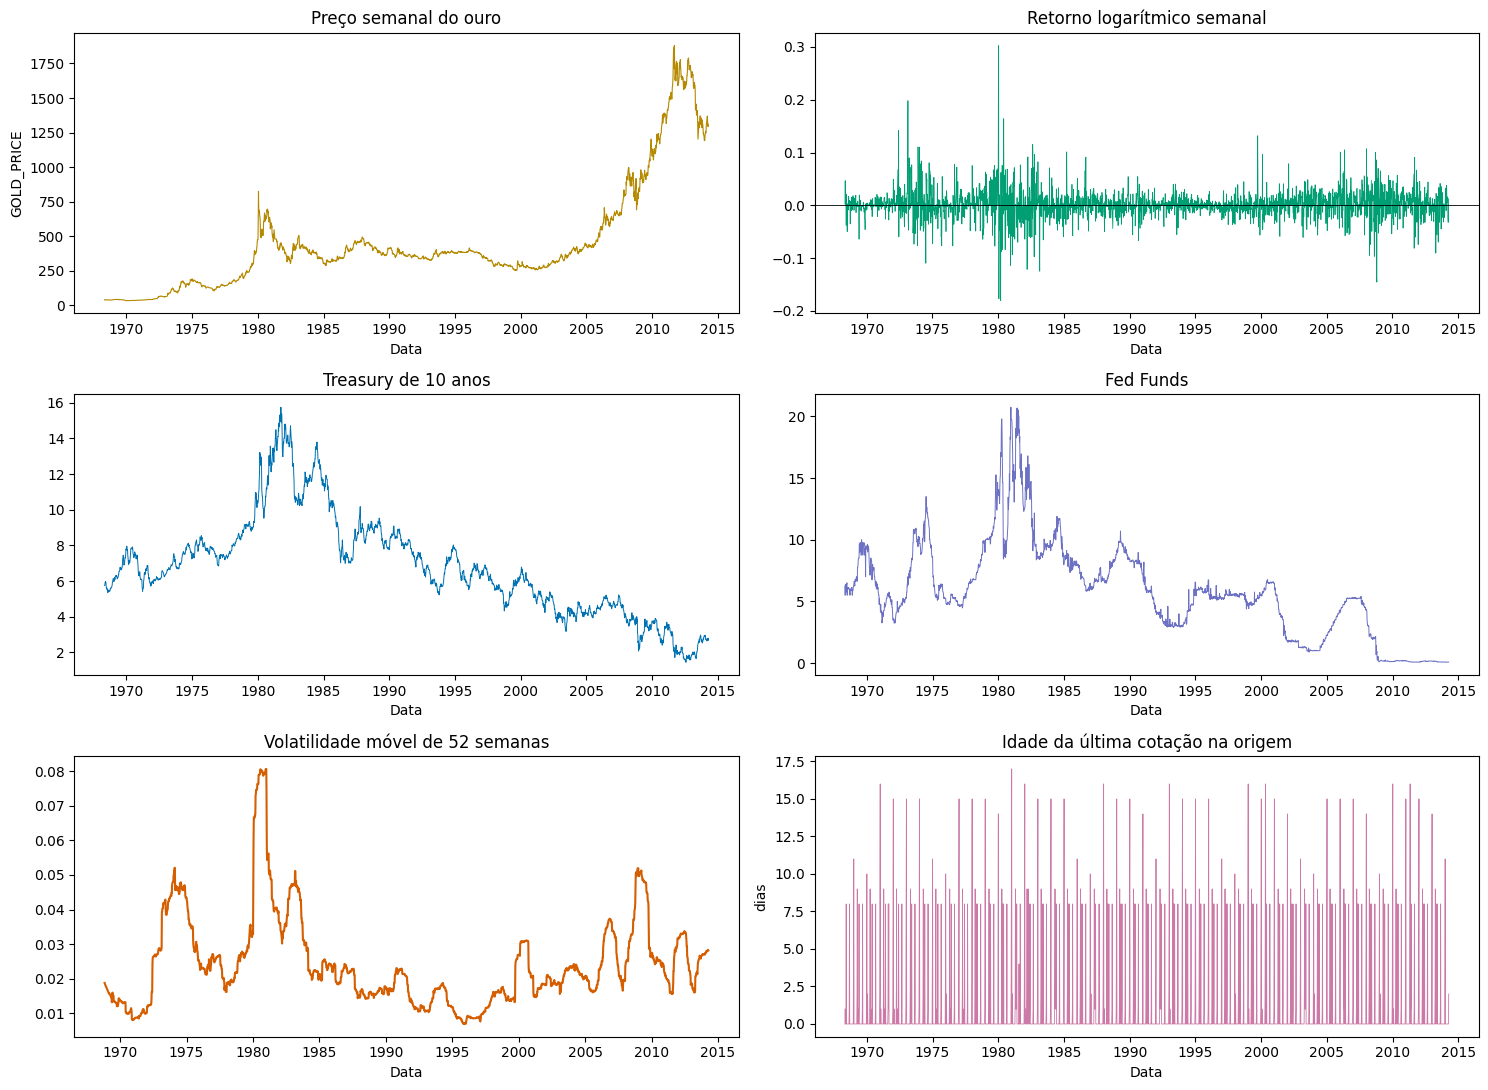

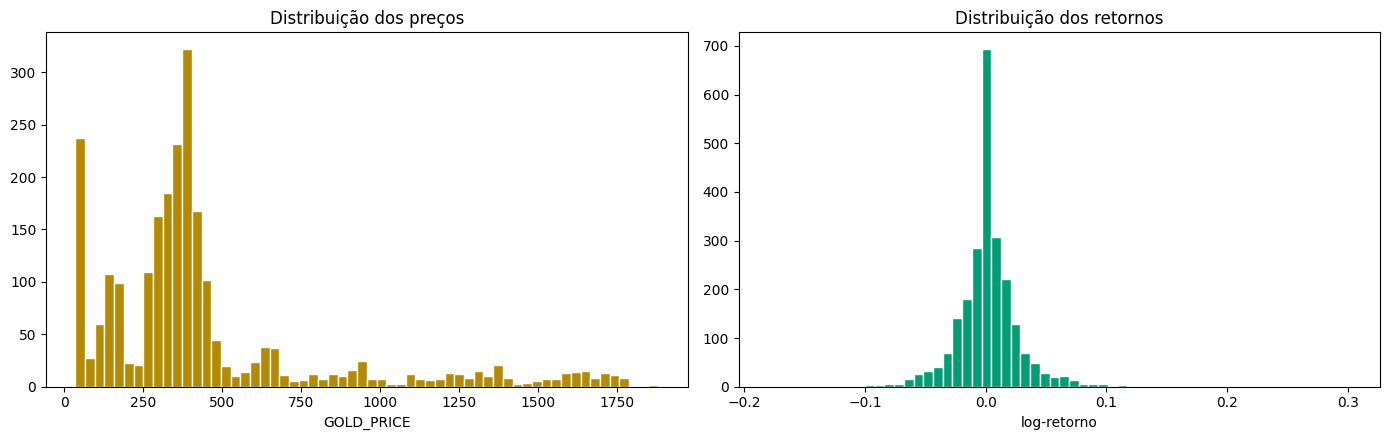

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes[0, 0].plot(weekly.DATE, weekly.price_t, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço semanal do ouro', ylabel='GOLD_PRICE')
axes[0, 1].plot(weekly.DATE, weekly.log_return_t, lw=.55, color='#009e73')
axes[0, 1].axhline(0, color='black', lw=.6); axes[0, 1].set(title='Retorno logarítmico semanal')
axes[1, 0].plot(weekly.DATE, weekly.treasury_10y_t, lw=.7, color='#0072b2')
axes[1, 0].set(title='Treasury de 10 anos')
axes[1, 1].plot(weekly.DATE, weekly.fed_funds_rate_t, lw=.7, color='#6c71c4')
axes[1, 1].set(title='Fed Funds')
axes[2, 0].plot(weekly.DATE, weekly.log_return_t.rolling(52, min_periods=26).std(), color='#d55e00')
axes[2, 0].set(title='Volatilidade móvel de 52 semanas')
axes[2, 1].plot(weekly.DATE, weekly.quote_age_days, lw=.6, color='#cc79a7')
axes[2, 1].set(title='Idade da última cotação na origem', ylabel='dias')
for ax in axes.flat: ax.set_xlabel('Data')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(weekly.price_t, bins=60, edgecolor='white', color='#b58900')
axes[0].set(title='Distribuição dos preços', xlabel='GOLD_PRICE')
axes[1].hist(weekly.log_return_t.dropna(), bins=60, edgecolor='white', color='#009e73')
axes[1].set(title='Distribuição dos retornos', xlabel='log-retorno')
plt.tight_layout(); plt.show()

## 5. STL e força da sazonalidade

A STL robusta usa apenas os 75% iniciais da série semanal. A força sazonal é
`max(0, 1 - Var(R) / Var(S + R))`; a força da tendência usa fórmula análoga.

,componente,forca,periodo_stl
0,sazonalidade,0.000000,52
1,tendência,0.927517,52


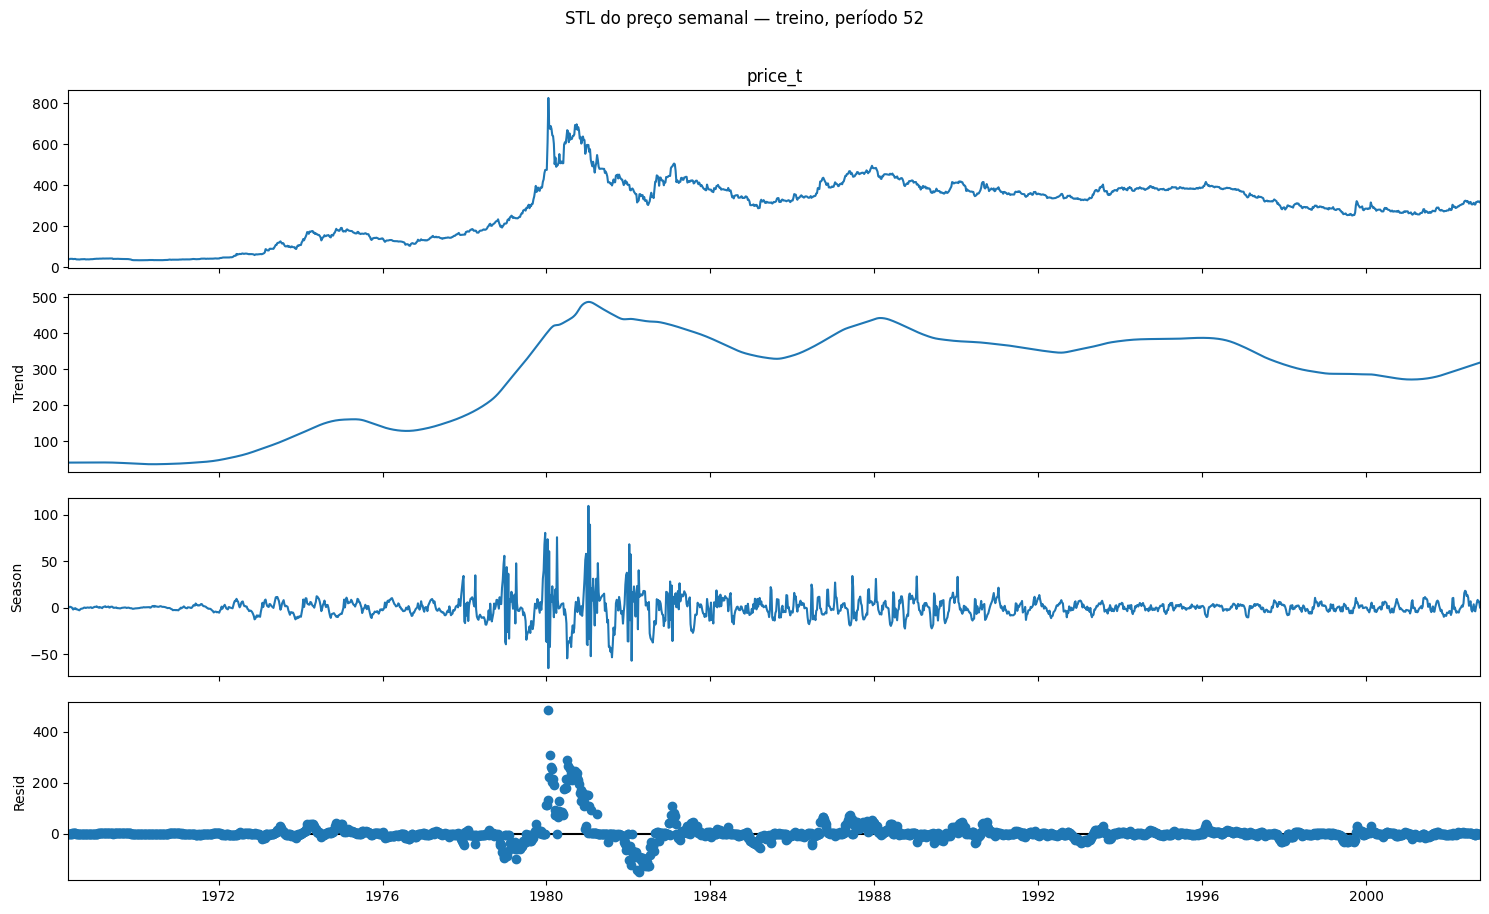

Interpretação: força sazonal 0.000 e força de tendência 0.928. A tendência apresenta crescimento líquido de 277.43 unidades no treino. O resíduo concentra variação não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.


In [6]:
stl_cut = int(len(weekly) * TRAIN_RATIO)
stl_series = weekly.iloc[:stl_cut].set_index('DATE').price_t.asfreq(WEEKLY_RULE)
assert stl_series.notna().all() and len(stl_series) >= 2 * STL_PERIOD
stl_result = STL(stl_series, period=STL_PERIOD, robust=True).fit()
resid_var = np.var(stl_result.resid, ddof=1)
seasonal_strength = max(0., 1. - resid_var / np.var(stl_result.seasonal + stl_result.resid, ddof=1))
trend_strength = max(0., 1. - resid_var / np.var(stl_result.trend + stl_result.resid, ddof=1))
display(pd.DataFrame({
    'componente': ['sazonalidade', 'tendência'],
    'forca': [seasonal_strength, trend_strength], 'periodo_stl': STL_PERIOD,
}))
fig = stl_result.plot(); fig.set_size_inches(15, 9)
fig.suptitle('STL do preço semanal — treino, período 52', y=1.01)
plt.tight_layout(); plt.show()
trend_change = float(stl_result.trend.iloc[-1] - stl_result.trend.iloc[0])
trend_direction = 'crescimento' if trend_change > 0 else 'queda' if trend_change < 0 else 'estabilidade'
print(
    f'Interpretação: força sazonal {seasonal_strength:.3f} e força de tendência '
    f'{trend_strength:.3f}. A tendência apresenta {trend_direction} líquido de '
    f'{abs(trend_change):.2f} unidades no treino. O resíduo concentra variação '
    'não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.'
)

## 6. Features, corte temporal, ADF, ACF e PACF

Lags e janelas são reconstruídos depois da agregação semanal. Datas-alvo,
preço futuro e todas as derivações entregues no CSV ficam fora de `X`.

,recorte,linhas,inicio_origem,fim_origem
0,treino — grade completa,1757,1969-05-09,2003-01-03
1,treino — alvos observados,1570,1969-05-09,2003-01-03
2,teste,586,2003-01-17,2014-04-04


,serie,estatistica,p_valor,lags
0,log do preço semanal — treino,-2.511253,1.127602e-01,8
1,retorno log semanal — treino,-14.203771,1.769288e-26,7


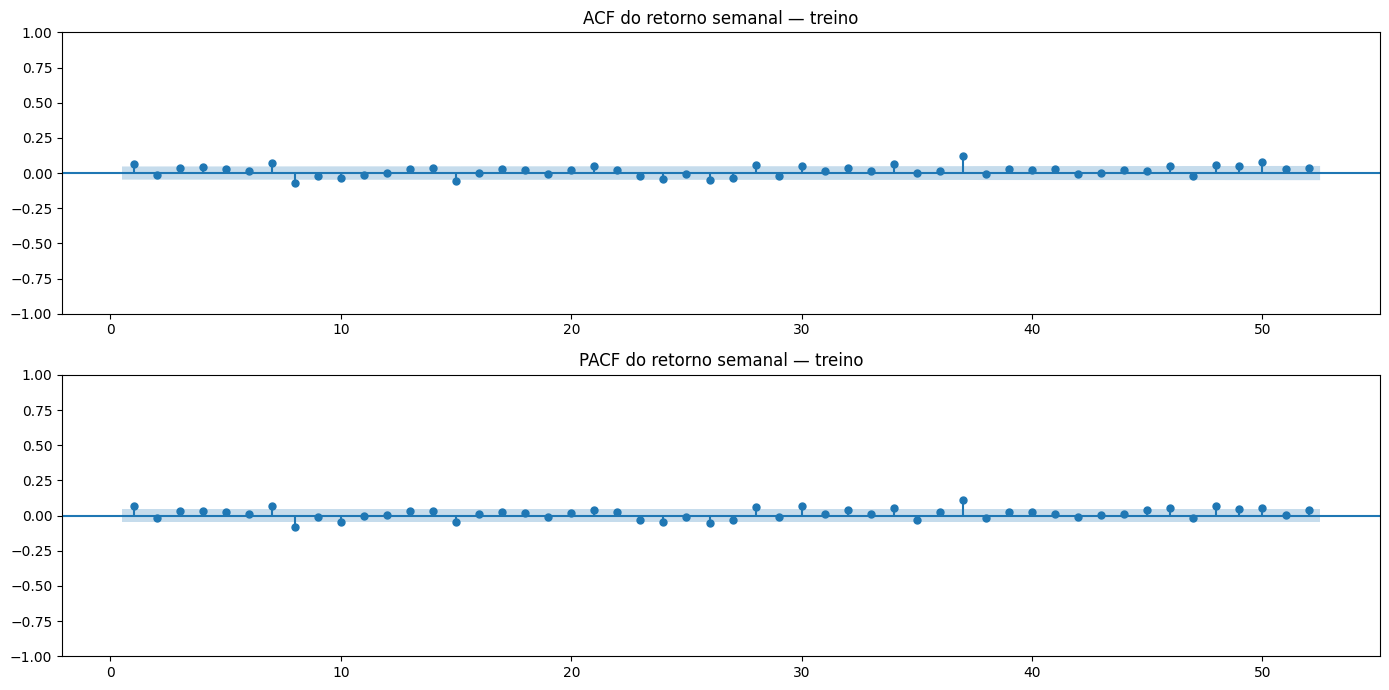

In [7]:
model_df, feature_columns = construir_quadro_ouro(weekly)
split_index = int(len(model_df) * TRAIN_RATIO)
first_test_origin = model_df.iloc[split_index].DATE
train_df = model_df.iloc[:split_index].loc[lambda x: x.target_date < first_test_origin].reset_index(drop=True)
test_df = model_df.iloc[split_index:].reset_index(drop=True)
training_df = selecionar_alvos_observados(train_df)
X_train, y_train = training_df[feature_columns], training_df[TARGET]
X_test, y_test = test_df[feature_columns], test_df[TARGET]
assert train_df.target_date.max() < test_df.DATE.min()
assert not set(derived_source_columns).intersection(feature_columns)
assert 'target_has_new_quote' not in feature_columns
assert training_df.target_has_new_quote.eq(1).all()

def adf_row(name, series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'serie': name, 'estatistica': result[0], 'p_valor': result[1], 'lags': result[2]}
display(pd.DataFrame({
    'recorte': ['treino — grade completa', 'treino — alvos observados', 'teste'],
    'linhas': [len(train_df), len(training_df), len(test_df)],
    'inicio_origem': [train_df.DATE.min(), training_df.DATE.min(), test_df.DATE.min()],
    'fim_origem': [train_df.DATE.max(), training_df.DATE.max(), test_df.DATE.max()],
}))
display(pd.DataFrame([
    adf_row('log do preço semanal — treino', train_df.log_price_t),
    adf_row('retorno log semanal — treino', train_df.log_return_t),
]))
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_df.log_return_t, lags=52, zero=False, ax=axes[0])
plot_pacf(train_df.log_return_t, lags=52, zero=False, method='ywm', ax=axes[1])
axes[0].set_title('ACF do retorno semanal — treino')
axes[1].set_title('PACF do retorno semanal — treino')
plt.tight_layout(); plt.show()

## 7. Otimização temporal do Random Forest

O desenho investiga explicitamente `n_estimators`, `max_depth`,
`min_samples_split`, `min_samples_leaf` e `max_features` em três dobras
expansivas purgadas. O teste final não participa da seleção.

In [8]:
candidates = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': .7},
]
cv_splits = purged_time_series_splits(training_df.DATE, training_df.target_date, n_splits=3)
search_rows = []
search_start = time.perf_counter()
for candidate_id, params in enumerate(candidates, start=1):
    fold_maes, fold_seconds = [], []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        candidate = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        fold_start = time.perf_counter()
        candidate.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        prediction = candidate.predict(X_train.iloc[validation_idx])
        fold_seconds.append(time.perf_counter() - fold_start)
        fold_maes.append(mean_absolute_error(y_train.iloc[validation_idx], prediction))
    search_rows.append({
        'candidate_id': candidate_id, **params,
        'mean_validation_mae': np.mean(fold_maes),
        'std_validation_mae': np.std(fold_maes, ddof=1),
        'fit_seconds': np.sum(fold_seconds),
    })
search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae', 'std_validation_mae', 'candidate_id']
).reset_index(drop=True)
best_params = {key: search_results.iloc[0][key] for key in candidates[0]}
for key in ('n_estimators', 'min_samples_split', 'min_samples_leaf'):
    best_params[key] = int(best_params[key])
best_params['max_depth'] = None if pd.isna(best_params['max_depth']) else int(best_params['max_depth'])
display(search_results)
print('Melhores parâmetros:', best_params)
print(f'Tempo de busca: {search_seconds:.2f} s')

,candidate_id,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mean_validation_mae,std_validation_mae,fit_seconds
0,6,250,6.0,2,3,sqrt,0.018952,0.010458,2.695896
1,3,100,6.0,2,1,sqrt,0.019699,0.011280,2.105968
2,5,100,NaN,2,3,sqrt,0.019712,0.010909,1.444876
3,8,250,6.0,10,3,0.7,0.019883,0.011411,4.732499
4,4,100,12.0,10,1,sqrt,0.020300,0.011783,1.441892
5,2,250,NaN,2,1,sqrt,0.020904,0.011911,4.755144
6,1,100,NaN,2,1,sqrt,0.020958,0.012242,3.050127
7,9,250,12.0,5,2,0.7,0.021647,0.012575,9.675888
8,7,100,NaN,2,1,0.7,0.023174,0.013098,5.211109


Melhores parâmetros: {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Tempo de busca: 35.25 s


## 8. Walk-forward final e importância das features

Os parâmetros permanecem fixos. O modelo é reajustado a cada 26 semanas por
limitação computacional; cada origem ainda recebe previsão fora da amostra.
O ajuste só recebe alvos observados e estritamente anteriores à nova origem. A periodicidade
é provisória e deverá ser igualada aos demais modelos no protocolo final.

,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,y_pred_return_rf,model_refit_origin,training_target_cutoff,y_pred_return_zero,price_pred_rf,price_pred_persistence,residual_return_rf,residual_price_rf,absolute_error_price_rf
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,0.002540,2003-01-17,2003-01-10,0.0,359.110904,358.20,0.013797,4.989096,4.989096
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,0.003074,2003-01-17,2003-01-10,0.0,365.220833,364.10,0.013946,5.129167,5.129167
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,0.002765,2003-01-17,2003-01-10,0.0,371.375393,370.35,-0.002225,-0.825393,0.825393
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,0.003128,2003-01-17,2003-01-10,0.0,371.710923,370.55,-0.042484,-15.460923,15.460923
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,0.001425,2003-01-17,2003-01-10,0.0,356.758185,356.25,-0.007761,-2.758185,2.758185


,feature,importance_mean,importance_std,grupo
0,return_mean_52,0.074129,0.002866,historico_ou_cobertura
1,log_return_t,0.054442,0.004619,historico_ou_cobertura
2,return_mean_26,0.041127,0.004930,historico_ou_cobertura
3,return_lag_26,0.037140,0.004794,historico_ou_cobertura
4,return_lag_2,0.031018,0.002571,historico_ou_cobertura
5,return_mean_13,0.030409,0.003280,historico_ou_cobertura
6,fed_funds_lag_4,0.029016,0.005095,externa_na_origem
7,return_std_13,0.028627,0.002473,historico_ou_cobertura
8,price_std_13,0.028327,0.002916,historico_ou_cobertura
9,return_lag_13,0.027296,0.002264,historico_ou_cobertura


,grupo,importance_mean
0,calendario,0.039285
1,externa_na_origem,0.169987
2,historico_ou_cobertura,0.790728


Externas mais importantes (importância nativa, não causal):


,feature,importance_mean,importance_std,grupo
6,fed_funds_lag_4,0.029016,0.005095,externa_na_origem
15,fed_funds_lag_1,0.022580,0.003316,externa_na_origem
22,fed_funds_rate_t,0.019979,0.002043,externa_na_origem
26,fed_funds_change_t,0.016812,0.001552,externa_na_origem
29,treasury_10y_t,0.015640,0.001589,externa_na_origem
30,fed_funds_lag_13,0.015576,0.002020,externa_na_origem
31,treasury_lag_1,0.014574,0.001606,externa_na_origem
35,treasury_lag_4,0.012666,0.001262,externa_na_origem


Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; nenhuma taxa observada da semana-alvo entra em X.


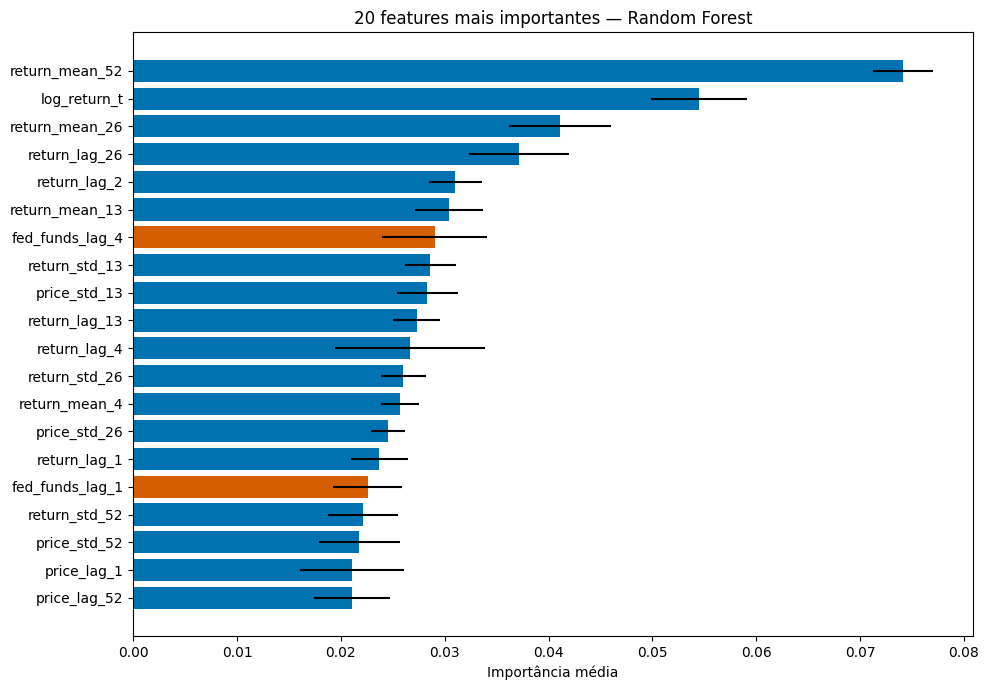

In [9]:
prediction_values, prediction_refits, training_cutoffs = [], [], []
fit_rows, importance_rows = [], []
evaluation_start = time.perf_counter()
for block_start in range(0, len(test_df), REFIT_EVERY):
    block_end = min(block_start + REFIT_EVERY, len(test_df))
    current_origin = test_df.iloc[block_start].DATE
    known_test = test_df.target_date < current_origin
    history_all = pd.concat([train_df, test_df.loc[known_test]], ignore_index=True)
    history = selecionar_alvos_observados(history_all)
    model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    fit_start = time.perf_counter()
    model.fit(history[feature_columns], history[TARGET])
    prediction_values.extend(model.predict(X_test.iloc[block_start:block_end]))
    prediction_refits.extend([current_origin] * (block_end - block_start))
    training_cutoff = history.target_date.max()
    training_cutoffs.extend([training_cutoff] * (block_end - block_start))
    fit_rows.append({
        'origem_refit': current_origin, 'linhas_historico': len(history_all),
        'linhas_alvos_observados': len(history),
        'inicio_bloco': block_start, 'fim_bloco_exclusivo': block_end,
        'fit_seconds': time.perf_counter() - fit_start,
    })
    importance_rows.append(model.feature_importances_)
evaluation_seconds = time.perf_counter() - evaluation_start
predictions = test_df[['DATE', 'target_date', 'price_t', 'target_price_t_plus_1', TARGET, 'target_has_new_quote']].copy()
predictions = predictions.rename(columns={TARGET: 'y_true_return'})
predictions['y_pred_return_rf'] = np.asarray(prediction_values)
predictions['model_refit_origin'] = prediction_refits
predictions['training_target_cutoff'] = training_cutoffs
assert (predictions.training_target_cutoff < predictions.DATE).all()
predictions['y_pred_return_zero'] = 0.
predictions['price_pred_rf'] = predictions.price_t * np.exp(predictions.y_pred_return_rf)
predictions['price_pred_persistence'] = predictions.price_t
predictions['residual_return_rf'] = predictions.y_true_return - predictions.y_pred_return_rf
predictions['residual_price_rf'] = predictions.target_price_t_plus_1 - predictions.price_pred_rf
predictions['absolute_error_price_rf'] = predictions.residual_price_rf.abs()
fit_log = pd.DataFrame(fit_rows)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance_mean': np.mean(importance_rows, axis=0),
    'importance_std': np.std(importance_rows, axis=0),
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
external_prefixes = ('treasury_', 'fed_funds_')
feature_importance['grupo'] = np.select(
    [feature_importance.feature.str.startswith(external_prefixes),
     feature_importance.feature.str.startswith(('price_', 'return_', 'log_', 'source_', 'quote_', 'weeks_'))],
    ['externa_na_origem', 'historico_ou_cobertura'], default='calendario',
)
display(predictions.head())
display(feature_importance.head(20))
display(feature_importance.groupby('grupo', as_index=False).importance_mean.sum())
print('Externas mais importantes (importância nativa, não causal):')
display(feature_importance.loc[feature_importance.grupo.eq('externa_na_origem')].head(8))
print(
    'Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; '
    'nenhuma taxa observada da semana-alvo entra em X.'
)
fig, ax = plt.subplots(figsize=(10, 7))
top = feature_importance.head(20).sort_values('importance_mean')
palette = {'externa_na_origem': '#d55e00', 'historico_ou_cobertura': '#0072b2', 'calendario': '#009e73'}
ax.barh(top.feature, top.importance_mean, xerr=top.importance_std,
        color=top.grupo.map(palette))
ax.set(title='20 features mais importantes — Random Forest', xlabel='Importância média')
plt.tight_layout(); plt.show()

## 9. MAE e demais métricas

A avaliação principal usa semanas-alvo com cotação nova. As linhas sobre toda
a grade são uma sensibilidade, pois retornos gerados por carregamento não são realizações observadas.

In [10]:
def metric_row(name, return_prediction, price_prediction, subset=None):
    mask = pd.Series(True, index=predictions.index) if subset is None else subset
    actual_return = predictions.loc[mask, 'y_true_return']
    predicted_return = np.asarray(return_prediction)[mask.to_numpy()]
    actual_price = predictions.loc[mask, 'target_price_t_plus_1']
    predicted_price = np.asarray(price_prediction)[mask.to_numpy()]
    return {
        'modelo': name, 'observacoes': int(mask.sum()),
        'MAE_retorno': mean_absolute_error(actual_return, predicted_return),
        'RMSE_retorno': mean_squared_error(actual_return, predicted_return) ** .5,
        'MedAE_retorno': median_absolute_error(actual_return, predicted_return),
        'R2_retorno': r2_score(actual_return, predicted_return),
        'vies_retorno': np.mean(actual_return - predicted_return),
        'acuracia_direcional': np.mean(np.sign(actual_return) == np.sign(predicted_return)),
        'MAE_preco': mean_absolute_error(actual_price, predicted_price),
    }
new_quote = predictions.target_has_new_quote.eq(1)
metrics = pd.DataFrame([
    metric_row('Random Forest — nova cotação', predictions.y_pred_return_rf, predictions.price_pred_rf, new_quote),
    metric_row('Persistência — nova cotação', predictions.y_pred_return_zero, predictions.price_pred_persistence, new_quote),
    metric_row('Random Forest — todas (sensibilidade)', predictions.y_pred_return_rf, predictions.price_pred_rf),
    metric_row('Persistência — todas (sensibilidade)', predictions.y_pred_return_zero, predictions.price_pred_persistence),
])
metrics['skill_mae_preco_vs_persistencia'] = np.nan
for suffix in ('nova cotação', 'todas (sensibilidade)'):
    baseline_mae = metrics.loc[metrics.modelo.eq(f'Persistência — {suffix}'), 'MAE_preco'].iloc[0]
    scope = metrics.modelo.str.endswith(suffix)
    metrics.loc[scope, 'skill_mae_preco_vs_persistencia'] = 1 - metrics.loc[scope, 'MAE_preco'] / baseline_mae
display(metrics)

,modelo,observacoes,MAE_retorno,RMSE_retorno,MedAE_retorno,R2_retorno,vies_retorno,acuracia_direcional,MAE_preco,skill_mae_preco_vs_persistencia
0,Random Forest — nova cotação,523,0.023132,0.030884,0.018354,-0.060084,0.004895,0.500956,21.673504,-0.020655
1,Persistência — nova cotação,523,0.022522,0.030098,0.018257,-0.006830,0.002479,0.001912,21.234895,0.000000
2,Random Forest — todas (sensibilidade),586,0.021128,0.029272,0.016712,-0.066217,0.004684,0.447099,19.793316,-0.044394
3,Persistência — todas (sensibilidade),586,0.020101,0.028434,0.016044,-0.006091,0.002212,0.109215,18.951962,0.000000


## 10. Registro de parâmetros, versões e tempo

O registro reúne hash, configuração, features, parâmetros, versões, tempos e
cada reajuste do teste para reprodução completa.

In [11]:
experiment_record = pd.DataFrame([{
    'base': 'Base 5 — ouro semanal', 'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash, 'frequencia': WEEKLY_RULE,
    'alvo': TARGET, 'horizonte_provisorio': '1 semana',
    'split_treino': TRAIN_RATIO, 'random_state': RANDOM_STATE,
    'linhas_treino_grade': len(train_df), 'linhas_treino_alvo_observado': len(training_df),
    'linhas_teste': len(test_df), 'linhas_teste_alvo_observado': int(test_df.target_has_new_quote.sum()),
    'origem_teste_inicial': test_df.DATE.min(), 'origem_teste_final': test_df.DATE.max(),
    'numero_features': len(feature_columns),
    'features': json.dumps(feature_columns, ensure_ascii=False),
    'candidatos_tuning': len(candidates), 'dobras_validacao': len(cv_splits),
    'melhores_parametros': json.dumps(best_params, ensure_ascii=False),
    'tempo_busca_s': search_seconds, 'tempo_walk_forward_s': evaluation_seconds,
    'numero_refits_teste': len(fit_log), 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit_learn': sklearn.__version__, 'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 5 — ouro semanal
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
frequencia,W-FRI
alvo,target_log_return_t_plus_1
horizonte_provisorio,1 semana
split_treino,0.75
random_state,42
linhas_treino_grade,1757
linhas_treino_alvo_observado,1570


,origem_refit,linhas_historico,linhas_alvos_observados,inicio_bloco,fim_bloco_exclusivo,fit_seconds
0,2003-01-17,1757,1570,0,26,1.646895
1,2003-07-18,1782,1592,26,52,1.572243
2,2004-01-16,1808,1616,52,78,1.507190
3,2004-07-16,1834,1639,78,104,1.753200
4,2005-01-14,1860,1662,104,130,1.726958
5,2005-07-15,1886,1685,130,156,1.496134
6,2006-01-13,1912,1708,156,182,1.559759
7,2006-07-14,1938,1731,182,208,2.556186
8,2007-01-12,1964,1754,208,234,1.960204
9,2007-07-13,1990,1777,234,260,1.689043


## 11. Resíduos individuais

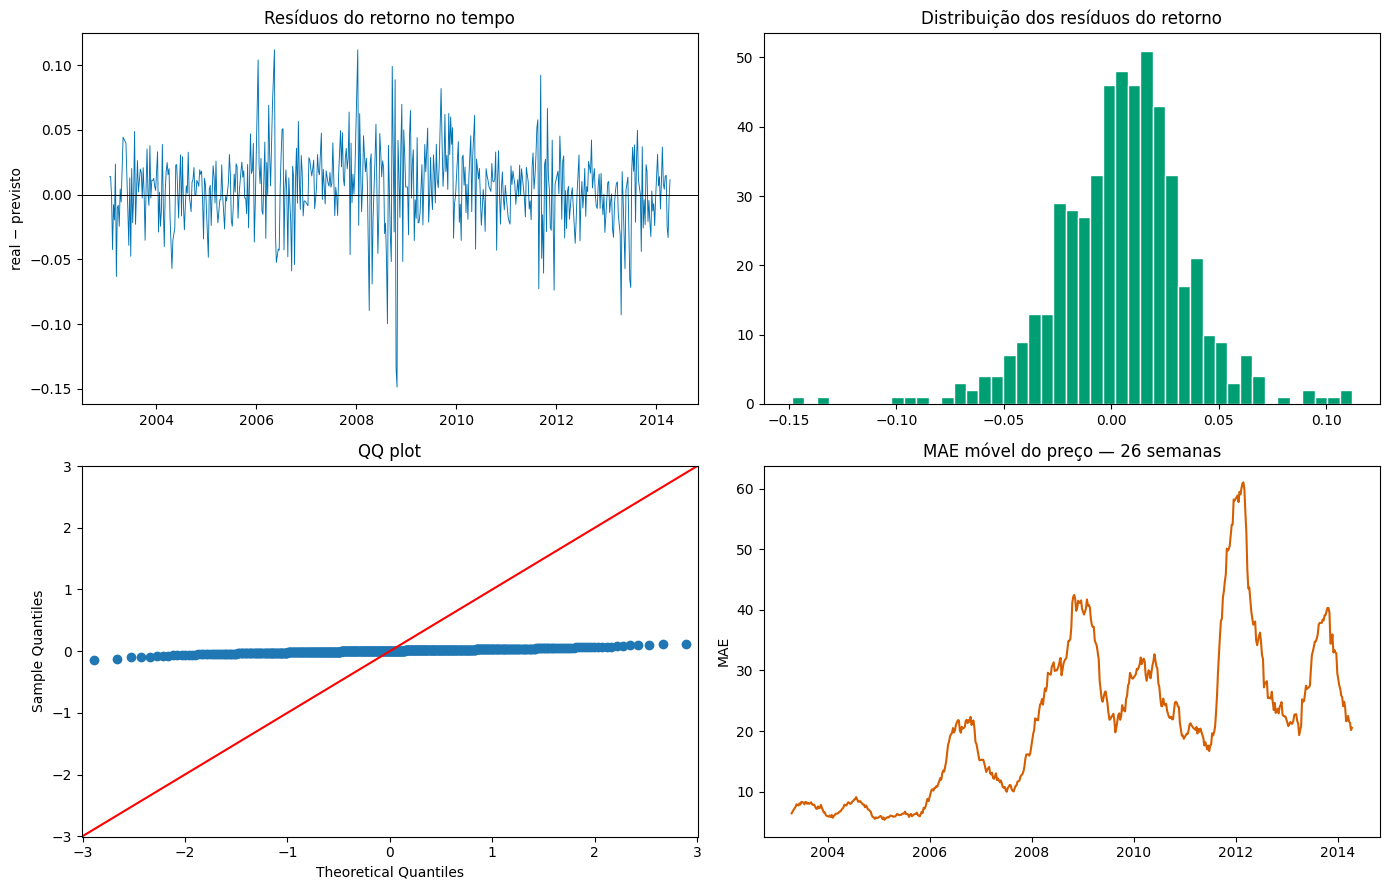

,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,y_pred_return_rf,model_refit_origin,training_target_cutoff,y_pred_return_zero,price_pred_rf,price_pred_persistence,residual_return_rf,residual_price_rf,absolute_error_price_rf
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,0.002540,2003-01-17,2003-01-10,0.0,359.110904,358.20,0.013797,4.989096,4.989096
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,0.003074,2003-01-17,2003-01-10,0.0,365.220833,364.10,0.013946,5.129167,5.129167
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,0.002765,2003-01-17,2003-01-10,0.0,371.375393,370.35,-0.002225,-0.825393,0.825393
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,0.003128,2003-01-17,2003-01-10,0.0,371.710923,370.55,-0.042484,-15.460923,15.460923
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,0.001425,2003-01-17,2003-01-10,0.0,356.758185,356.25,-0.007761,-2.758185,2.758185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,2014-03-07,2014-03-14,1348.25,1370.00,0.016003,1,0.001045,2014-01-03,2013-12-27,0.0,1349.659458,1348.25,0.014958,20.340542,20.340542
582,2014-03-14,2014-03-21,1370.00,1338.50,-0.023261,1,0.002060,2014-01-03,2013-12-27,0.0,1372.825301,1370.00,-0.025321,-34.325301,34.325301
583,2014-03-21,2014-03-28,1338.50,1295.75,-0.032460,1,0.000691,2014-01-03,2013-12-27,0.0,1339.425206,1338.50,-0.033151,-43.675206,43.675206
584,2014-03-28,2014-04-04,1295.75,1293.50,-0.001738,1,0.001011,2014-01-03,2013-12-27,0.0,1297.060784,1295.75,-0.002749,-3.560784,3.560784


In [12]:
observed_predictions = predictions.loc[predictions.target_has_new_quote.eq(1)].copy()
residuals = observed_predictions.residual_return_rf
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(observed_predictions.target_date, residuals, lw=.65, color='#0072b2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title='Resíduos do retorno no tempo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=45, edgecolor='white', color='#009e73')
axes[0, 1].set(title='Distribuição dos resíduos do retorno')
sm.qqplot(residuals, line='45', ax=axes[1, 0]); axes[1, 0].set_title('QQ plot')
axes[1, 1].plot(observed_predictions.target_date, observed_predictions.absolute_error_price_rf.rolling(26, min_periods=13).mean(), color='#d55e00')
axes[1, 1].set(title='MAE móvel do preço — 26 semanas', ylabel='MAE')
plt.tight_layout(); plt.show()
display(predictions)

## 12. ACF dos resíduos e Ljung–Box

A ACF e o Ljung–Box verificam se o RF deixou dependência temporal nos erros.
Rejeição a 5% indica que o resíduo não se comporta como ruído branco.

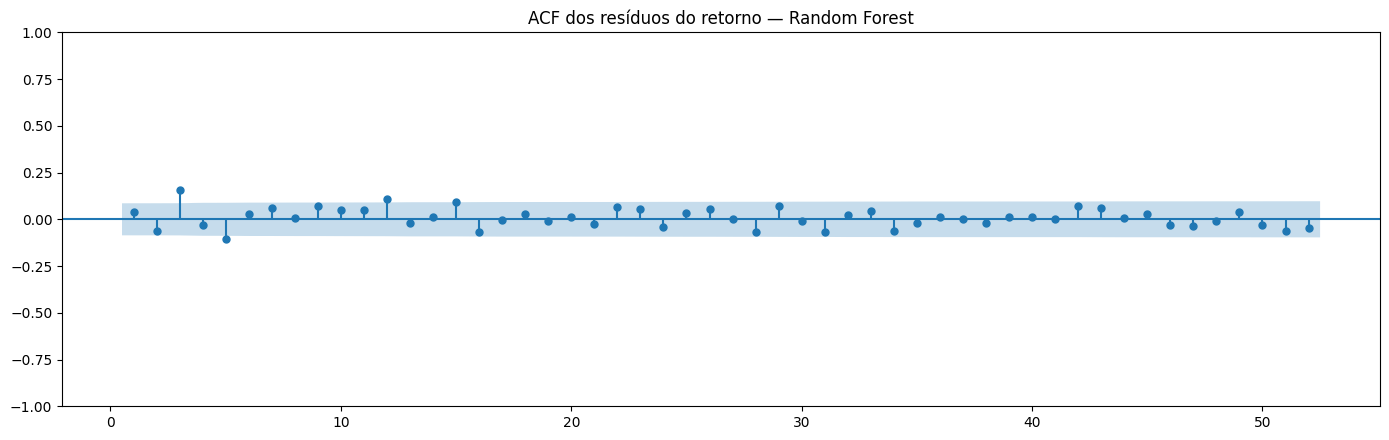

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,0.822046,0.364583,False
4,16.543831,0.002370,True
13,36.807883,0.000444,True
26,52.131163,0.001735,True


In [13]:
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=52, zero=False, ax=ax)
ax.set_title('ACF dos resíduos do retorno — Random Forest')
plt.tight_layout(); plt.show()
ljung_box = acorr_ljungbox(residuals, lags=[1, 4, 13, 26], return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)

## 13. Previsões e métricas do preço do ouro

O modelo continua sendo ajustado sobre o retorno logarítmico, mas esta seção
expõe sua saída final na unidade de interesse: o preço do ouro da semana
seguinte. Todas as linhas abaixo são previsões fora da amostra do walk-forward;
as métricas e o gráfico principal usam apenas semanas com cotação nova.

Métricas de erro do preço — fora da amostra e com cotação nova:


,modelo,observacoes,MAE_preco,RMSE_preco,MedAE_preco,MAPE_preco_pct,R2_preco,vies_preco_real_menos_previsto,skill_MAE_vs_persistencia
0,Random Forest via retorno,523,21.673504,31.478635,14.468057,2.306829,0.995275,3.968152,-0.020655
1,Persistência,523,21.234895,31.029890,14.000000,2.251740,0.995409,1.819407,0.000000


Previsão de preço mais recente disponível no teste:


,585
data_origem,2014-04-04 00:00:00
data_prevista,2014-04-11 00:00:00
preco_na_origem,1293.5
preco_real,1309.75
preco_previsto_rf,1294.819006
preco_previsto_persistencia,1293.5
tem_cotacao_nova,1
erro_rf,14.930994
erro_absoluto_rf,14.930994
erro_percentual_absoluto_rf_pct,1.139988


Últimas 20 previsões de preço:


,data_origem,data_prevista,preco_na_origem,preco_real,preco_previsto_rf,preco_previsto_persistencia,tem_cotacao_nova,erro_rf,erro_absoluto_rf,erro_percentual_absoluto_rf_pct
566,2013-11-22,2013-11-29,1241.75,1245.25,1241.795802,1241.75,1,3.454198,3.454198,0.277390
567,2013-11-29,2013-12-06,1245.25,1230.75,1246.453786,1245.25,1,-15.703786,15.703786,1.275953
568,2013-12-06,2013-12-13,1230.75,1222.75,1231.241718,1230.75,1,-8.491718,8.491718,0.694477
569,2013-12-13,2013-12-20,1222.75,1195.00,1223.938125,1222.75,1,-28.938125,28.938125,2.421600
570,2013-12-20,2013-12-27,1195.00,1192.75,1195.097220,1195.00,1,-2.347220,2.347220,0.196791
571,2013-12-27,2014-01-03,1192.75,1192.75,1193.741169,1192.75,0,-0.991169,0.991169,0.083099
572,2014-01-03,2014-01-10,1192.75,1232.25,1194.589635,1192.75,1,37.660365,37.660365,3.056228
573,2014-01-10,2014-01-17,1232.25,1241.00,1232.680195,1232.25,1,8.319805,8.319805,0.670411
574,2014-01-17,2014-01-24,1241.00,1259.25,1241.899596,1241.00,1,17.350404,17.350404,1.377836
575,2014-01-24,2014-01-31,1259.25,1246.50,1260.379098,1259.25,1,-13.879098,13.879098,1.113445


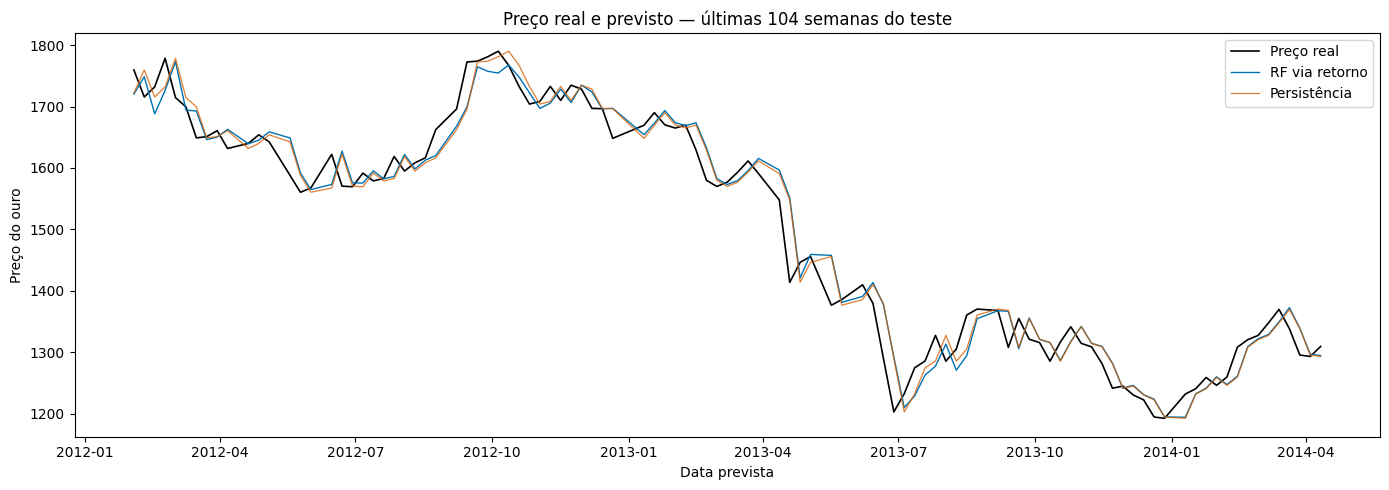

In [14]:
price_forecasts = predictions[[
    'DATE', 'target_date', 'price_t', 'target_price_t_plus_1',
    'price_pred_rf', 'price_pred_persistence', 'target_has_new_quote',
]].copy()
price_forecasts = price_forecasts.rename(columns={
    'DATE': 'data_origem',
    'target_date': 'data_prevista',
    'price_t': 'preco_na_origem',
    'target_price_t_plus_1': 'preco_real',
    'price_pred_rf': 'preco_previsto_rf',
    'price_pred_persistence': 'preco_previsto_persistencia',
    'target_has_new_quote': 'tem_cotacao_nova',
})
price_forecasts['erro_rf'] = price_forecasts.preco_real - price_forecasts.preco_previsto_rf
price_forecasts['erro_absoluto_rf'] = price_forecasts.erro_rf.abs()
price_forecasts['erro_percentual_absoluto_rf_pct'] = (
    100 * price_forecasts.erro_absoluto_rf / price_forecasts.preco_real
)


def price_metric_row(name, values):
    mask = price_forecasts.tem_cotacao_nova.eq(1)
    actual = price_forecasts.loc[mask, 'preco_real']
    predicted = np.asarray(values)[mask.to_numpy()]
    return {
        'modelo': name,
        'observacoes': len(actual),
        'MAE_preco': mean_absolute_error(actual, predicted),
        'RMSE_preco': mean_squared_error(actual, predicted) ** .5,
        'MedAE_preco': median_absolute_error(actual, predicted),
        'MAPE_preco_pct': np.mean(np.abs((actual - predicted) / actual)) * 100,
        'R2_preco': r2_score(actual, predicted),
        'vies_preco_real_menos_previsto': np.mean(actual - predicted),
    }


price_error_metrics = pd.DataFrame([
    price_metric_row('Random Forest via retorno', price_forecasts.preco_previsto_rf),
    price_metric_row('Persistência', price_forecasts.preco_previsto_persistencia),
])
baseline_mae_price = price_error_metrics.loc[
    price_error_metrics.modelo.eq('Persistência'), 'MAE_preco'
].iloc[0]
price_error_metrics['skill_MAE_vs_persistencia'] = (
    1 - price_error_metrics.MAE_preco / baseline_mae_price
)

print('Métricas de erro do preço — fora da amostra e com cotação nova:')
display(price_error_metrics)
print('Previsão de preço mais recente disponível no teste:')
display(price_forecasts.tail(1).T)
print('Últimas 20 previsões de preço:')
display(price_forecasts.tail(20))

plot_data = price_forecasts.loc[price_forecasts.tem_cotacao_nova.eq(1)].tail(104)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_data.data_prevista, plot_data.preco_real, label='Preço real', color='black', lw=1.2)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_rf,
        label='RF via retorno', color='#0072b2', lw=1)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_persistencia,
        label='Persistência', color='#d55e00', lw=.9, alpha=.8)
ax.set(title='Preço real e previsto — últimas 104 semanas do teste',
       xlabel='Data prevista', ylabel='Preço do ouro')
ax.legend()
plt.tight_layout(); plt.show()